In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots

scenarios_dict_for_plots = ['multisector_1zone']

load_files_dict = {
    "multisector_1zone": {
        "folder_name" : "multisector_1zone_ethanoldehydration_addethanol",
        "results": "results_002/results",
        "base_path": "/Users/abbie/MacroEnergy-Abbie.jl/MacroEnergyExamples/ETHYLENESYSTEM_ethylene"
    },
}
zones = ['SE']

commodity_mapping = {
    "NaturalGas": "natgas",
    "Fossil_NaturalGas": "fossil_natgas",
    "Electricity": "elec",
    "Biomass_Agri": "bioagri",
    "Biomass_Herb": "bioherb",
    "Biomass_Wood": "biowood",
    "Biomass_Corn": "corn",
    "Ethanol": "ethanol",
    "E10": "e10",
    "Gasoline": "gasoline",
    "Diesel": "diesel",
    "JetFuel": "jetfuel",
    "Fossil_JetFuel": "fossil_jetfuel",
    "Fossil_Gasoline": "fossil_gasoline",
    "Fossil_Gasoline_Blendstock": "fossil_gasoline_blendstock",
    "Fossil_Diesel": "fossil_diesel",
    "CO2Captured": "co2_captured",
    "Hydrogen": "h2",
    "Ethane": "ethane",
    "Ethylene" : "ethylene"
}

multi_zone_mapping = ["co2_sink"]

# list of demand nodes that don't have a special fuel usage asset
final_demand_nodes_list = ['Electricity']

# list of nodes that have a nsd as an option
nsd_nodes_list = ['Electricity','Hydrogen','Gasoline','Diesel','JetFuel','NaturalGas','Ethylene']

In [52]:
# Create a 1:1 mapping where each week is its own representative period
period_map_df = pd.DataFrame({
    'Period_Index': list(range(1, 53)),      # Weeks 1-52
    'Rep_Period': list(range(1, 53)),        # Each week represents itself
    'Rep_Period_Index': list(range(1, 53))   # Sequential index 1-52
})

# Save it
#period_map_df.to_csv('/Users/abbie/MacroEnergy-Abbie.jl/MacroEnergyExamples/examples/electricity_3zone/system/Period_Map.csv', index=False)

In [53]:
# manually change based on time weights
hours_per_year = 8760
weeks_per_year = 52
hours_per_rep_week = 168
scaling_factor = hours_per_year / (weeks_per_year * hours_per_rep_week)

total_hrs_in_rep_period = 504

## colors-mapping

In [54]:
# ------------- MANUALLY ASSIGN COLORS -------------
# colors based off of component_id
# component_id is used to distinguish "DryMill" from "DryMillCCS" using _commodity phrases
asset_colors = {
    "Ethylene": {
        "TSC_Non_CCS": "#e07b54",              # burnt orange
        "TSC_CCS_90": "#c0392b",               # deep red
        "TSC_Non_CCS_H2prod": "#f4a261",       # light orange
        "TSC_CCS_90_H2prod": "#e76f51",        # coral
        "TSC_Non_CCS_H2fuel": "#d4a373",       # tan
        "ESC": "#2a9d8f",                      # teal
        "Ethanol_Dehydration_NGfuel": "#8ab17d", # sage green
        "Ethanol_Dehydration_H2fuel": "#52b788", # medium green
        "Synthetic_Ethylene_Non_CCS": "#457b9d", # steel blue
        "Synthetic_Ethylene_CCS_90": "#1d3557",  # navy
        "Ethylene_End_Use" : "indigo",
    },
    "Electricity": {
        "Multiproduct_elec_edge": "plum",
        "Diesel_elec_edge": "plum",
        "Gasoline_elec_edge": "plum",

        "Ethanol_Bio_elec_edge": "plum",
        "Ethanol_BioCCS_20_elec_edge": "plum",
        "DryMillCCS_elec": "goldenrod",
        "DryMill_elec": "goldenrod",
        "DryMillCCS_RETROFIT_elec": "goldenrod",

        "natural_gas_fired_combined_cycle": "firebrick",
        "natural_gas_combined_cycle_elec": "firebrick",
        "natural_gas_fired_combustion_turbine": "firebrick",
        "naturalgas_ccccsavgcf_conservative": "red",
        "naturalgas_ccavgcf": "red",
        "naturalgas_ctavgcf": "red",

        "utilitypv": "lemonchiffon",
        "solar_pv": "lemonchiffon",
        "existing_solar": "khaki",
        "solar_photovoltaic": "yellow",
        "existing_wind": "steelblue",
        "landbasedwind": "lightskyblue",
        "onshore_wind_turbine": "lightskyblue",
        "onshore_wind": "lightskyblue",
        "offshorewind_class10_moderate_floating_1_1_edge": "steelblue",

        "conventional_hydroelectric_1_discharge_edge": "lightseagreen",
        "pumpedhydro": "lightseagreen",
        "hydroelectric_pumped_storage_1_charge_edge": "lightseagreen",
        "small_hydroelectric_1_elec_edge": "lightseagreen",
        "hydroelectric_pumped_storage_1_discharge_edge": "paleturquoise",

        "Electricity_demand": "indigo",

        "battery": "mediumpurple",

        "Above_ground_storage_external_discharge_elec_edge" : "cadetblue",
        "Above_ground_storage_external_charge_elec_edge" : "cadetblue",
        "Above_ground_storage_discharge_elec_edge": "paleturquoise",
        "Above_ground_storage_charge_elec_edge": "paleturquoise",

        "SE_CCGT-H2_elec_edge" : "deepskyblue",
        "OCGT-H2_elec_edge" : "deepskyblue",
        "Electrolyzer_elec_edge": "paleturquoise",
        "CCGT-H2_elec_edge": "paleturquoise",
        "OCGT-H2_elec_edge": "paleturquoise",

        "nuclear_1_elec_edge" : "orange",
        "nuclear_2_elec_edge" : "orange",

        "Gasoline_Gasification_CCS_31_Herb_elec_consumption_edge" : "paleturquoise",
        "Gasoline_Gasification_CCS_31_Wood_elec_consumption_edge" : "paleturquoise",
        "Gasoline_Gasification_CCS_31_Agri_elec_consumption_edge" : "paleturquoise",
        "Gasoline_Gasification_CCS_99_Herb_elec_consumption_edge" : "paleturquoise",
        "Gasoline_Gasification_CCS_99_Wood_elec_consumption_edge" : "paleturquoise",
        "Gasoline_Gasification_CCS_99_Agri_elec_consumption_edge" : "paleturquoise",

        "Synfuel_Plant_elec_edge": "lightseagreen",

        "Large_SMR_wCCS_96pct_elec_edge": "paleturquoise",
        "Large_SMR_Non_CCS_elec_edge": "paleturquoise",
        "ATR_wCCS_94pct_elec_edge": "paleturquoise",

        "Bio_H2_Wood_elec_edge": "paleturquoise",
        "Bio_H2_Herb_elec_edge": "paleturquoise",
        "Bio_H2_Agri_elec_edge": "paleturquoise",
        "Bio_H2_CCS_99_Wood_elec_edge": "paleturquoise",
        "Bio_H2_CCS_99_Herb_elec_edge": "paleturquoise",
        "Bio_H2_CCS_99_Agri_elec_edge": "paleturquoise",

        "Bio_NG_CCS_40_Wood_elec_edge": "paleturquoise",
        "Bio_NG_CCS_40_Herb_elec_edge": "paleturquoise",
        "Bio_NG_CCS_40_Agri_elec_edge": "paleturquoise",
        "Bio_NG_CCS_99_Wood_elec_edge": "paleturquoise",
        "Bio_NG_CCS_99_Herb_elec_edge": "paleturquoise",
        "Bio_NG_CCS_99_Agri_elec_edge": "paleturquoise",

        "Bio_Electricity_CCS_93_Wood_elec_edge": "paleturquoise",
        "Bio_Electricity_CCS_93_Herb_elec_edge": "paleturquoise",
        "Bio_Electricity_CCS_93_Agri_elec_edge": "paleturquoise",

        "Solvent_wNGCC_DAC_elec_edge": "paleturquoise",
        "Sorbent_DAC_elec_edge": "paleturquoise",
        
    },
     "NaturalGas": {
        "Bio_H2_Wood_natgas_edge": "green",
        "Bio_H2_Herb_natgas_edge": "green",
        "Bio_H2_Agri_natgas_edge": "green",
        "Bio_H2_CCS_99_Wood_natgas_edge": "green",
        "Bio_H2_CCS_99_Herb_natgas_edge": "green",
        "Bio_H2_CCS_99_Agri_natgas_edge": "green",
        "Bio_H2_Agri_natgas_edge": "green",
        "Bio_H2_Wood_natgas_edge": "green",
        "Bio_H2_Herb_natgas_edge": "green",
    },
    "Diesel": {
        "Ethanol_Diesel_Upgrade_diesel_edge": "gold",
        "Ethanol_Multiproduct_Upgrade_diesel_edge": "#F4A300",
        "Diesel_Fossil_Upstream_fuel_edge": "black",
        "Diesel_Use_fuel_edge": "indigo",
        "Synfuel_Plant_diesel_edge": "magenta",

        "FT_High_Diesel_Non_CCS_Wood_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Wood_diesel_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Agri_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_Agri_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Agri_diesel_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Herb_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_diesel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Herb_diesel_edge": "#2F6B2F",
    },
    "JetFuel": {
        "Ethanol_JetFuel_Upgrade_jetfuel_edge": "gold",
        "JetFuel_Fossil_Upstream_fuel_edge": "black",
        "JetFuel_Use_fuel_edge": "indigo",
        "Synfuel_Plant_jetfuel_edge": "magenta",

        "FT_High_Jetfuel_CCS_84_Wood_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Wood_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Wood_jetfuel_edge": "#3AAFA9",

        "FT_High_Diesel_CCS_99_Wood_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Wood_jetfuel_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Herb_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Herb_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Herb_jetfuel_edge": "#3AAFA9",

        "FT_High_Diesel_CCS_99_Herb_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Herb_jetfuel_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Agri_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Agri_jetfuel_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Agri_jetfuel_edge": "#3AAFA9",
        
        "FT_High_Diesel_CCS_99_Agri_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Agri_jetfuel_edge": "#2F6B2F",
        "FT_High_Diesel_Agri_jetfuel_edge": "#2F6B2F",
    },

     "Gasoline": {
        "e10_gasoline_edge": "indigo",
        "Gasoline_Fossil_Upstream_fuel_edge": "black",
        "Ethanol_Gasoline_Upgrade_gasoline_edge": "gold",
        "Ethanol_Multiproduct_Upgrade_gasoline_edge": "#F4A300",
        "Gasoline_Use_fuel_edge": "indigo",
        "Synfuel_Plant_gasoline_edge": "magenta",
        
        "Gasoline_Gasification_Non_CCS_Agri_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Agri_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Agri_gasoline_edge": "#A4BF3B",

        "Gasoline_Gasification_Non_CCS_Herb_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Herb_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Herb_gasoline_edge": "#A4BF3B",

        "Gasoline_Gasification_Non_CCS_Wood_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Wood_gasoline_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Wood_gasoline_edge": "#A4BF3B",

        "FT_High_Jetfuel_CCS_84_Wood_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Wood_gasoline_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Wood_gasoline_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Wood_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Wood_gasoline_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Herb_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Herb_gasoline_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Herb_gasoline_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Herb_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Herb_gasoline_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Agri_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Agri_gasoline_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Agri_gasoline_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Agri_gasoline_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Agri_gasoline_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Wood_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Wood_gasoline_edge": "#2F6B2F",

        "FT_High_Diesel_Agri_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Agri_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Agri_gasoline_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Herb_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_gasoline_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Herb_gasoline_edge": "#2F6B2F",
    },
    "Ethanol": {
        "DryMill_Existing_Non_CCS": "orange",
        "DryMill_CCS_60_RETROFIT_ethanol": "goldenrod",
        "DryMill_CCS_90_RETROFIT_ethanol": "gold",
        "Ethanol_Use_fuel": "indigo",
        "Biochemical_Non_CCS": "orange",
        "Biochemical_CCS_20": "darkorange",
        "Biochemical_CCS_86": "darkorange",
        "Ethanol_Multiproduct_Upgrade_ethanol_edge": "#B5C85A",
        "Ethanol_Diesel_Upgrade_ethanol_edge": "#2F6B2F",
        "e10_ethanol_edge": "indigo",
        "Ethanol_JetFuel_Upgrade_ethanol_edge": "#3AAFA9",
        "Ethanol_Gasoline_Upgrade_ethanol_edge": "#A4BF3B",
    },
    "NaturalGas" : {
        "DryMillCCS_natgas": "darkorange",
        "DryMill_natgas": "gold",
        "DryMillCCS_RETROFIT_natgas": "orange",
        "NG_Fossil_Upstream_fuel" : "black",
        "Sorbent_wNGCC_DAC" : "blue",
        "NG_End_Use_fuel_edge": "indigo",
        "Large_SMR_Non_CCS_fuel_edge": "deepskyblue",
        "Large_SMR_wCCS_96pct_fuel_edge": "deepskyblue",
        "ATR_wCCS_94pct_fuel_edge": "deepskyblue",
        "naturalgas_ccccsavgcf_conservative_0_fuel_edge": "red",
        "Syn_NG_Plant_natgas_edge": "magenta",
        "Synthetic_NaturalGas_natgas_edge": "deeppink",

        "DryMillCCS_60_RETROFIT_natgas_edge": "goldenrod",
        "DryMillCCS_90_RETROFIT_natgas_edge": "darkgoldenrod",

        "Solvent_DAC_natgas_edge": "#00A8A8",
        "Solvent_wNGCC_DAC_natgas_edge": "#00A8A8",

        "Bio_NG_Wood_natgas_edge": "green",
        "Bio_NG_Herb_natgas_edge": "green",
        "Bio_NG_Agri_natgas_edge": "green",
        "Bio_NG_CCS_40_Wood_natgas_edge": "green",
        "Bio_NG_CCS_40_Herb_natgas_edge": "green",
        "Bio_NG_CCS_40_Agri_natgas_edge": "green",
        "Bio_NG_CCS_99_Wood_natgas_edge": "green",
        "Bio_NG_CCS_99_Herb_natgas_edge": "green",
        "Bio_NG_CCS_99_Agri_natgas_edge": "green",

        "Bio_H2_Wood_natgas_edge": "green",
        "Bio_H2_Herb_natgas_edge": "green",
        "Bio_H2_Agri_natgas_edge": "green",
        "Bio_H2_CCS_99_Wood_natgas_edge": "green",
        "Bio_H2_CCS_99_Herb_natgas_edge": "green",
        "Bio_H2_CCS_99_Agri_natgas_edge": "green",

    },
    "CO2" : {
        "DryMillCCS_60_RETROFIT_co2_edge": "gold",
        "DryMillCCS_90_RETROFIT_co2_edge": "gold",
        "DryMillCCS_60_RETROFIT_co2_emission_edge": "gold",
        "DryMillCCS_90_RETROFIT_co2_emission_edge": "gold",
        "DryMillCCS_co2_edge": "gold",
        "DryMillCCS_co2_emission_edge" : "gold",
        "DryMill_co2_edge" : "gold",
        "DryMill_co2_emission_edge" : "gold",
        "Ethanol_BioCCS_80_co2_emission_edge" : "gold",
        "Ethanol_BioCCS_20_co2_emission_edge" : "gold",
        "Ethanol_BioCCS_20_co2_edge" : "gold",
        "Ethanol_BioCCS_80_co2_edge" : "gold",

        "Ethanol_Use_co2_edge" : "gold",

        "Gasoline_Gasification_CCS_31_Herb_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Herb_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Herb_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Herb_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Herb_co2_edge": "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Herb_co2_emission_edge": "#A4BF3B",

        "Gasoline_Gasification_CCS_31_Agri_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Agri_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Agri_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Agri_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Agri_co2_edge": "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Agri_co2_emission_edge": "#A4BF3B",

        "Gasoline_Gasification_CCS_31_Wood_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Wood_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Wood_co2_edge" : "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Wood_co2_emission_edge" : "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Wood_co2_edge": "#A4BF3B",
        "Gasoline_Gasification_Non_CCS_Wood_co2_emission_edge": "#A4BF3B",

        "Bio_H2_Wood_co2_emission_edge" : "turquoise",
        "Bio_H2_Herb_co2_emission_edge" : "turquoise",
        "Bio_H2_Agri_co2_emission_edge" : "turquoise",
        "Bio_H2_Wood_co2_edge" : "turquoise",
        "Bio_H2_Herb_co2_edge" : "turquoise",
        "Bio_H2_Agri_co2_edge" : "turquoise",
        "Bio_H2_CCS_99_Wood_co2_emission_edge" : "turquoise",
        "Bio_H2_CCS_99_Herb_co2_emission_edge" : "turquoise",
        "Bio_H2_CCS_99_Agri_co2_emission_edge" : "turquoise",
        "Bio_H2_CCS_99_Wood_co2_edge" : "turquoise",
        "Bio_H2_CCS_99_Herb_co2_edge" : "turquoise",
        "Bio_H2_CCS_99_Agri_co2_edge" : "turquoise",
        "ATR_wCCS_94pct_co2_edge" : "turquoise",

        "Bio_Electricity_CCS_93_Wood_co2_edge" : "lightblue",
        "Bio_Electricity_CCS_93_Herb_co2_edge" : "lightblue",
        "Bio_Electricity_CCS_93_Agri_co2_edge" : "lightblue",
        "Bio_Electricity_CCS_93_Wood_co2_emission_edge" : "lightblue",
        "Bio_Electricity_CCS_93_Herb_co2_emission_edge" : "lightblue",
        "Bio_Electricity_CCS_93_Agri_co2_emission_edge" : "lightblue",

        "Solvent_wNGCC_DAC_co2_emission_edge" : "#00A8A8",
        "Solvent_wNGCC_DAC_co2_edge" : "#00A8A8",
        "Sorbent_wNGCC_DAC_co2_edge" : "#00A8A8",
        "Sorbent_DAC_co2_edge" : "#00A8A8",

        "Bio_NG_CCS_40_Wood_co2_edge" : "crimson",
        "Bio_NG_CCS_40_Herb_co2_edge" : "crimson",
        "Bio_NG_CCS_40_Agri_co2_edge" : "crimson",
        "Bio_NG_CCS_40_Wood_co2_emission_edge" : "crimson",
        "Bio_NG_CCS_40_Herb_co2_emission_edge" : "crimson",
        "Bio_NG_CCS_40_Agri_co2_emission_edge" : "crimson",
        "Bio_NG_Wood_co2_edge" : "crimson",
        "Bio_NG_Herb_co2_edge" : "crimson",
        "Bio_NG_Agri_co2_edge" : "crimson",
        "Bio_NG_Wood_co2_emission_edge" : "crimson",
        "Bio_NG_Herb_co2_emission_edge" : "crimson",
        "Bio_NG_Agri_co2_emission_edge" : "crimson",
        "Bio_NG_CCS_99_Wood_co2_edge" : "crimson",
        "Bio_NG_CCS_99_Herb_co2_edge" : "crimson",
        "Bio_NG_CCS_99_Agri_co2_edge" : "crimson",
        "Bio_NG_CCS_99_Wood_co2_emission_edge" : "crimson",
        "Bio_NG_CCS_99_Herb_co2_emission_edge" : "crimson",
        "Bio_NG_CCS_99_Agri_co2_emission_edge" : "crimson",

        "JetFuel_Use_co2_edge" : "#3AAFA9",
        "Diesel_Use_co2_edge" : "#2F6B2F",
        "Gasoline_E10_Use_co2_edge" : "#A4BF3B",

        "Diesel_co2_emission_edge" : "#2F6B2F",
        "JetFuel_co2_emission_edge" : "#3AAFA9",
        "Gasoline_co2_emission_edge" : "#A4BF3B",
        "Multiproduct_co2_emission_edge" : "#A4BF3B",

        "NG_End_Use_co2_edge" : "crimson",

        "Synfuel_Plant_co2_emission_edge" : "magenta",
        "Large_SMR_wCCS_96pct_co2_edge": "turquoise",
        "Large_SMR_Non_CCS_co2_edge": "turquoise",

        "FT_High_Jetfuel_CCS_84_Wood_co2_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Wood_co2_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Wood_co2_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Wood_co2_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Wood_co2_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Herb_co2_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Herb_co2_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Herb_co2_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Herb_co2_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Herb_co2_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Agri_co2_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Agri_co2_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Agri_co2_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Agri_co2_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Agri_co2_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Wood_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Wood_co2_edge": "#2F6B2F",

        "FT_High_Diesel_Agri_co2_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Agri_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Agri_co2_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Herb_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_co2_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Herb_co2_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Wood_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Wood_co2_emission_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Wood_co2_emission_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Wood_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Wood_co2_emission_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Herb_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Herb_co2_emission_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Herb_co2_emission_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Herb_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Herb_co2_emission_edge": "#2F6B2F",

        "FT_High_Jetfuel_CCS_84_Agri_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_CCS_53_Agri_co2_emission_edge": "#2F6B2F",
        "FT_High_Jetfuel_CCS_75_Agri_co2_emission_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Agri_co2_emission_edge": "#3AAFA9",
        "FT_High_Diesel_Non_CCS_Agri_co2_emission_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Wood_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Wood_co2_emission_edge": "#2F6B2F",

        "FT_High_Diesel_Agri_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Agri_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Agri_co2_emission_edge": "#2F6B2F",

        "FT_High_Diesel_Non_CCS_Herb_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_co2_emission_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Herb_co2_emission_edge": "#2F6B2F",
        
    },
    "Hydrogen" : {
        "Electrolyzer_h2_edge": "paleturquoise",
        "Hydrogen_demand_edge" : "indigo",
        "Above_ground_storage_external_discharge_edge" : "cadetblue",
        "Above_ground_storage_external_charge_edge" : "cadetblue",
        "CCGT-H2_fuel_edge" : "deepskyblue",
        "OCGT-H2_fuel_edge" : "deepskyblue",
        "Large_SMR_Non_CCS_h2_edge" : "darkslategray",
        "Bio_H2_Herb_h2_edge" : "green",
        "Bio_H2_Agri_h2_edge" : "green",
        "Bio_H2_Wood_h2_edge" : "green",
        "ATR_wCCS_94pct_h2_edge" : "deepskyblue",
        "Large_SMR_wCCS_96pct_h2_edge" : "deepskyblue",

        "Bio_H2_CCS_99_Agri_h2_edge" : "green",
        "Bio_H2_CCS_99_Herb_h2_edge" : "green",
        "Bio_H2_CCS_99_Wood_h2_edge" : "green",

        "Synfuel_Plant_h2_edge" : "magenta",
        "Syn_NG_Plant_h2" : "magenta",

        "Diesel_h2_edge" : "green",

        "Ethanol_JetFuel_Upgrade_h2_edge": "dodgerblue",
    },
    "Biomass_Agri" : {
        "Gasoline_Gasification_Non_CCS_Agri_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Agri_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Agri_biomass_edge": "#A4BF3B",

        "FT_High_Jetfuel_CCS_84_Agri_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Agri_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Agri_biomass_edge": "#3AAFA9",

        "FT_High_Diesel_Agri_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Agri_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Agri_biomass_edge": "#2F6B2F",

        "Ethanol_Bio_biomass_edge": "darkorange",
        "Ethanol_BioCCS_80_biomass_edge": "darkorange",
        "Ethanol_BioCCS_20_biomass_edge": "darkorange",

        "Bio_H2_Agri_biomass_edge": "turquoise",
        "Bio_H2_CCS_99_Agri_biomass_edge": "turquoise",

        "Bio_NG_Agri_biomass_edge": "crimson",
        "Bio_NG_CCS_40_Agri_biomass_edge": "crimson",
        "Bio_NG_CCS_99_Agri_biomass_edge": "crimson",

        "Bio_Electricity_CCS_93_Agri_biomass_edge": "lightblue"
    },
    "Biomass_Wood" : {
        "Gasoline_Gasification_Non_CCS_Wood_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Wood_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Wood_biomass_edge": "#A4BF3B",

        "FT_High_Jetfuel_CCS_84_Wood_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Wood_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Wood_biomass_edge": "#3AAFA9",

        "FT_High_Diesel_Wood_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Wood_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Wood_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Wood_biomass_edge": "#2F6B2F",

        "Bio_H2_Wood_biomass_edge": "turquoise",
        "Bio_H2_CCS_99_Wood_biomass_edge": "turquoise",

        "Bio_NG_Wood_biomass_edge": "crimson",
        "Bio_NG_CCS_40_Wood_biomass_edge": "crimson",
        "Bio_NG_CCS_99_Wood_biomass_edge": "crimson",

        "Bio_Electricity_CCS_93_Wood_biomass_edge": "lightblue"
    },
    "Biomass_Herb" : {
        "Gasoline_Gasification_Non_CCS_Herb_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_31_Herb_biomass_edge": "#A4BF3B",
        "Gasoline_Gasification_CCS_99_Herb_biomass_edge": "#A4BF3B",

        "FT_High_Jetfuel_CCS_84_Herb_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_75_Herb_biomass_edge": "#3AAFA9",
        "FT_High_Jetfuel_CCS_99_Herb_biomass_edge": "#3AAFA9",

        "FT_High_Diesel_Herb_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_Non_CCS_Herb_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_53_Herb_biomass_edge": "#2F6B2F",
        "FT_High_Diesel_CCS_99_Herb_biomass_edge": "#2F6B2F",

        "Bio_H2_Herb_biomass_edge": "turquoise",
        "Bio_H2_CCS_99_Herb_biomass_edge": "turquoise",

        "Bio_NG_Herb_biomass_edge": "crimson",
        "Bio_NG_CCS_40_Herb_biomass_edge": "crimson",
        "Bio_NG_CCS_99_Herb_biomass_edge": "crimson",

        "Bio_Electricity_CCS_93_Herb_biomass_edge": "lightblue"
    },
    "General": {
        "_to_": "gray",
        "nsd": "gray"
    }
}

## prepare-plots

In [55]:
# ------------- INITIALIZE NESTED DICTIONARY FOR EACH SCENARIO -------------
categories = ["flow_total","flow_by_commodity", "capacity", "lcoe", "commodities_list", "assets_list","demand","nsd","duals","costs","capacity","time_weights"]
scenario_plot_dict = {
    scenario_label: {category: {} for category in categories}
    for scenario_label in load_files_dict
}

def summarize_data_structure(data):
    for scenario, categories in data.items():
        print(f"\n📘 Scenario: {scenario}")
        for category, content in categories.items():
            if isinstance(content, dict) and content:
                print(f"  ├─ {category}:")
                for key, value in content.items():
                    if isinstance(value, dict):
                        print(f"  │   • {key} ({len(value)} sub-items)")
                    elif isinstance(value, list):
                        if all(isinstance(x, str) for x in value):
                            preview = ', '.join(value[:3]) + ("..." if len(value) > 3 else "")
                            print(f"  │   • {key} → list of {len(value)} strings [{preview}]")
                        else:
                            print(f"  │   • {key} → list of {len(value)} items")
                    elif hasattr(value, 'shape'):
                        print(f"  │   • {key} → DataFrame {value.shape}")
                    else:
                        print(f"  │   • {key} → {type(value).__name__}")
            elif isinstance(content, list) and content:
                print(f"  ├─ {category}: list of {len(content)} items")
            elif hasattr(content, 'shape'):
                print(f"  ├─ {category}: DataFrame {content.shape}")
            else:
                print(f"  ├─ {category}: (empty)")

                
summarize_data_structure(scenario_plot_dict)


📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: (empty)
  ├─ assets_list: (empty)
  ├─ demand: (empty)
  ├─ nsd: (empty)
  ├─ duals: (empty)
  ├─ costs: (empty)
  ├─ time_weights: (empty)


In [56]:
# ------------- Construct time weights FOR EACH SCENARIO using manually provided info + Period_map.csv -------------
for scenario_label in load_files_dict.keys():
    print("scenario_label: ", scenario_label)
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]

    path = base_path / folder_name / "system" / "Period_map.csv"

    rep_week_map_df = pd.read_csv(path)
    rep_week_counts = rep_week_map_df["Rep_Period_Index"].value_counts().sort_index() # what does this do?

    time_weights = [count * scaling_factor for count in rep_week_counts]
    full_time_weights = [w for w in time_weights for _ in range(hours_per_rep_week)]
    print("full_time_weights: ", full_time_weights) # a weight for each of the hours in the sample sub period mapping to the annual?
    print(len(full_time_weights))

    scenario_plot_dict[scenario_label]["time_weights"] = full_time_weights

scenario_label:  multisector_1zone
full_time_weights:  [23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.063186813186814, 23.0

In [57]:
# ------------- Add LIST OF COMMODITIES FOR EACH SCENARIO using flow.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / results / "flows.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)
    commodities = df["commodity"].astype(str).unique().tolist()

    # Save to data dictionary
    scenario_plot_dict[scenario_label]["commodities_list"] = commodities
    print(commodities)

summarize_data_structure(scenario_plot_dict)

['Biomass_Herb', 'Electricity', 'CO2', 'CO2Captured', 'Biomass_Wood', 'Gasoline', 'Hydrogen', 'JetFuel', 'Diesel', 'NaturalGas', 'Biomass_Corn', 'Ethanol', 'Fossil_Ethane', 'Ethane', 'Ethylene', 'Fossil_Gasoline', 'Fossil_JetFuel', 'Fossil_Diesel', 'Fossil_NaturalGas', 'Uranium']

📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: (empty)
  ├─ demand: (empty)
  ├─ nsd: (empty)
  ├─ duals: (empty)
  ├─ costs: (empty)
  ├─ time_weights: list of 504 items


In [58]:
# ------------- Add full LIST OF ASSET ID'S FOR EACH SCENARIO using flows.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / results / "flows.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)
    commodities = df["resource_id"].astype(str).unique().tolist()

    # Save to data dictionary
    scenario_plot_dict[scenario_label]["assets_list"] = commodities

summarize_data_structure(scenario_plot_dict)


📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: list of 85 items
  ├─ demand: (empty)
  ├─ nsd: (empty)
  ├─ duals: (empty)
  ├─ costs: (empty)
  ├─ time_weights: list of 504 items


In [59]:
# ------------- add the demand csv for the sample time period for each scenario using demand fuel.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / "system" / "demand_nameformat.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)

    df_sums = pd.DataFrame(df.sum()).T
    df_sums['Time_Index'] = len(df)
    display(df_sums)

    scenario_plot_dict[scenario_label]["demand"] = df_sums
    
summarize_data_structure(scenario_plot_dict)

,Time_Index,Electricity_MW_SE,Electricity_MW_MIDAT,Electricity_MW_NE,Hydrogen_Demand_SE,Hydrogen_Demand_MIDAT,Hydrogen_Demand_NE,NaturalGas_Demand_SE,NaturalGas_Demand_MIDAT,NaturalGas_Demand_NE,...,Gasoline_Demand_MIDAT,Gasoline_Demand_NE,JetFuel_Demand_SE,JetFuel_Demand_MIDAT,JetFuel_Demand_NE,Diesel_Demand_SE,Diesel_Demand_MIDAT,Diesel_Demand_NE,Demand_Zero,Ethylene_Demand_SE
0,504,6.319043e+07,4.753489e+07,2.512638e+07,7444710.0,3712428.72,913217.76,1.196551e+07,1.476147e+07,1.051089e+07,...,1.375189e+07,7877403.828,8.757595e+06,4.791936e+06,4.966527e+06,1.028238e+07,6.609628e+06,4.176142e+06,0.0,50400.0



📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: list of 85 items
  ├─ demand: DataFrame (1, 21)
  ├─ nsd: (empty)
  ├─ duals: (empty)
  ├─ costs: (empty)
  ├─ time_weights: list of 504 items


In [60]:
# ------------- add the NSD for the sampled time period for each scenario with nse.csv from get_results.jl -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    #time_weights = scenario_plot_dict[scenario_label]["time_weights"]
    
    path = base_path / folder_name / results / "nse.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)

    df_sums = pd.DataFrame(df.sum()).T
    df_sums['time'] = len(df)
    display(df_sums)

    # ✅ Save inside the loop (so each scenario gets saved properly)
    scenario_plot_dict[scenario_label]["nsd"] = df_sums
    
summarize_data_structure(scenario_plot_dict)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/abbie/MacroEnergy-Abbie.jl/MacroEnergyExamples/ETHYLENESYSTEM_ethylene/multisector_1zone_ethanoldehydration_addethanol/results_002/results/nse.csv'

In [61]:
# ------------- add the DISCOUNTED COSTS for each scenario with costs.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / results / "costs.csv"
    df = pd.read_csv(path)
    scenario_plot_dict[scenario_label]["costs"] = df
    
summarize_data_structure(scenario_plot_dict)


📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: list of 85 items
  ├─ demand: DataFrame (1, 21)
  ├─ nsd: (empty)
  ├─ duals: (empty)
  ├─ costs: DataFrame (3, 10)
  ├─ time_weights: list of 504 items


In [62]:
# ------------- add the duals for the sample time period for each scenario using balance_duals.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / results / "balance_duals.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)

    # Compute mean of non-zero values for each column
    #df_means = df.apply(lambda col: col[col != 0].mean() if (col != 0).any() else 0)
    df_means = df.mean()
    df_means = pd.DataFrame([df_means])  # Convert back to single-row DataFrame

    df_means['time'] = len(df_means)
    display(df_means)

    scenario_plot_dict[scenario_label]["duals"] = df_means
    
summarize_data_structure(scenario_plot_dict)

,natgas_SE,ethane_SE,natgas_demand_SE,biocorn_SE,biowood_SE,bioherb_SE,elec_SE,ethylene_SE,ethylene_demand_SE,h2_SE,co2_captured_SE,gasoline_SE,ethanol_SE,gasoline_demand_SE,jetfuel_SE,jetfuel_demand_SE,diesel_SE,diesel_demand_SE,time
0,-44.300576,21.98,148.398169,155.0,574.369025,573.168532,49.844032,244.86345,3369.147326,39.134852,-603.500392,94.95991,-116.917479,334.99095,-126.347262,118.776374,97.34841,348.922669,1



📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: (empty)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: list of 85 items
  ├─ demand: DataFrame (1, 21)
  ├─ nsd: (empty)
  ├─ duals: DataFrame (1, 19)
  ├─ costs: DataFrame (3, 10)
  ├─ time_weights: list of 504 items


In [63]:
# ------------- add capacity for each scenario using capacity.csv -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    path = base_path / folder_name / results / "capacity.csv"

    # Load file and extract unique commodities
    df = pd.read_csv(path)

    scenario_plot_dict[scenario_label]["capacity"] = df
    
summarize_data_structure(scenario_plot_dict)


📘 Scenario: multisector_1zone
  ├─ flow_total: (empty)
  ├─ flow_by_commodity: (empty)
  ├─ capacity: DataFrame (237, 8)
  ├─ lcoe: (empty)
  ├─ commodities_list: list of 20 items
  ├─ assets_list: list of 85 items
  ├─ demand: DataFrame (1, 21)
  ├─ nsd: (empty)
  ├─ duals: DataFrame (1, 19)
  ├─ costs: DataFrame (3, 10)
  ├─ time_weights: list of 504 items


In [64]:
# ------------- Add time weights to flow.csv results -------------
for scenario_label in load_files_dict.keys():
    # --- Load file paths ---
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    path = base_path / folder_name / results / "flows.csv"

    # --- Read the flow file ---
    flow_df = pd.read_csv(path)
    print(len(flow_df))

    # --- Get the time weights for this scenario ---
    full_time_weights = scenario_plot_dict[scenario_label]["time_weights"]

    # --- Prepare an empty list to collect processed dataframes ---
    weighted_list = []

    # --- Loop through each unique (commodity, component_id) combination ---
    for (commodity, component_id), df_for_one_commodity in flow_df.groupby(["commodity", "component_id"]):
        df_for_one_commodity = df_for_one_commodity.sort_values("time").reset_index(drop=True)

        # --- Check if the time steps match expectation ---
        if len(df_for_one_commodity) != total_hrs_in_rep_period:
            print(f"Skipping {commodity}-{component_id} — expected {total_hrs_in_rep_period} time steps, got {len(df_for_one_commodity)}.")
            continue

        # --- Add weight and weighted value columns ---
        df_for_one_commodity["time_weight"] = full_time_weights
        df_for_one_commodity["weighted_value"] = (
            df_for_one_commodity["value"] * df_for_one_commodity["time_weight"]
        )

        # --- Store for later concatenation ---
        weighted_list.append(df_for_one_commodity)

    # --- Combine all weighted data back into one dataframe ---
    weighted_flows = pd.concat(weighted_list, ignore_index=True)

    scenario_plot_dict[scenario_label]["flow_total"] = weighted_flows

    # --- Save to CSV to inspect ---
    out_path = base_path / folder_name / results / "flows_weighted.csv"
    weighted_flows.to_csv(out_path, index=False)

    print(f"✅ Saved weighted flows for {scenario_label} to {out_path}")

152208
✅ Saved weighted flows for multisector_1zone to /Users/abbie/MacroEnergy-Abbie.jl/MacroEnergyExamples/ETHYLENESYSTEM_ethylene/multisector_1zone_ethanoldehydration_addethanol/results_002/results/flows_weighted.csv


In [65]:
# ------------- ENERGY BALANCE PLOTS (function for non co2) -------------
# SET FLOW VALUES WITH SIGNS BASED ON PRODUCTION AND USAGE DIRECTION

def extract_zone_and_value(row, zones, lowercase_commodity):
    node_in = str(row.get('node_in', ''))
    node_out = str(row.get('node_out', ''))
    value = row['weighted_value']
    resource_id = row['resource_id']

    # Identify which zone (if any) matches node_in or node_out
    zone_in = next((z for z in zones if f"{lowercase_commodity}_{z}" == node_in), None)
    zone_out = next((z for z in zones if f"{lowercase_commodity}_{z}" == node_out), None)

    # Case 1: only node_in matches
    if zone_in and zone_out is None:
        #print('resource_id:', resource_id, 'zone_in:', zone_in)
        row['zone'] = zone_in
        row['weighted_value_flow'] = value * -1

    # Case 2: only node_out matches
    elif zone_out and zone_in is None:
        #print('resource_id:', resource_id, 'zone_out:', zone_out)
        row['zone'] = zone_out
        row['weighted_value_flow'] = value

    return row

In [66]:
# ------------- ENERGY BALANCE PLOTS -------------
for scenario_label in load_files_dict.keys():
    print(scenario_label)
    df = scenario_plot_dict[scenario_label]["flow_total"]
    commodities_list = scenario_plot_dict[scenario_label]["commodities_list"]
    time_weights = scenario_plot_dict[scenario_label]["time_weights"]

    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]

    for commodity in commodities_list:
        print(commodity)
        if commodity == "CO2":
            if "CO2" not in scenario_plot_dict[scenario_label]["flow_by_commodity"]:
                scenario_plot_dict[scenario_label]["flow_by_commodity"]["CO2"] = {}
            #dfs_by_sink = {} # will not be added to the total flow which is fine
            df_for_one_commodity = df[df["commodity"] == commodity].copy() # get only the CO2 rows
            #group_cols = [c for c in df_for_one_commodity.columns if c not in ["time", "weighted_value"]]
            #df_grouped = (df_for_one_commodity.groupby(group_cols, as_index=False).agg({"time": "count", "weighted_value": "sum"})) # group the rows by total time value
            # --------------------------
            group_cols = [
                "commodity", "commodity_subtype", "node_in", "node_out",
                "resource_id", "component_id", "type", "variable"
            ]

            df_grouped = (
                df_for_one_commodity
                .groupby(group_cols, as_index=False)
                .agg({
                    "time": "count",               # number of time steps (should be 504)
                    "weighted_value": "sum"        # total weighted sum
                })
            )
            df_grouped["time_weight"] = np.nan
            # --------------------------
            df_grouped['zone'] = np.nan
            df_grouped['weighted_value_flow'] = np.nan

            for co2_sink_label in multi_zone_mapping:
                df_sink = df_grouped[
                    (df_grouped["node_in"] == co2_sink_label) |
                    (df_grouped["node_out"] == co2_sink_label)
                ].copy() # Filter to rows where this sink appears in node_in or node_out

                if df_sink.empty:
                    continue  # skip if no matching rows

                df_sink["zone"] = "all"
                df_sink["weighted_value_flow"] = df_sink.apply(
                    lambda r: -r["weighted_value"] if str(r["node_in"]) == co2_sink_label else r["weighted_value"],
                    axis=1
                )
                print(f"Processed CO2 sink: {co2_sink_label}, rows: {len(df_sink)}")
                #display(df_sink)
                # Save the whole dict of sink-specific DataFrames

                out_path = base_path / folder_name / results / f'{commodity}_grouped_flow.csv'
                df_sink.to_csv(out_path, index=False)
                scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity][co2_sink_label] = df_sink
        
        else:
            lowercase_commodity = commodity_mapping.get(commodity, commodity.lower())
            df_for_one_commodity = df[df["commodity"] == commodity].copy()

            # get the format of the commodity node ie elec_SE
            zone_nodes = [f'{lowercase_commodity}_{z}' for z in zones]
            
            # only select rows showing interactions with that commodity node / will not necessarily be 504 since is likely to be going to several assets
                # elec_SE should be in node_in or node_out
            df_selected_node_only = df_for_one_commodity[
                df_for_one_commodity["node_in"].isin(zone_nodes) |
                df_for_one_commodity["node_out"].isin(zone_nodes)
            ].copy()

            # for every unique combination of commodity and component_id, group the time steps for values in 'time' from 1 to len(time_weights)
            # deposit the count of grouped rows into 'time'. Sum "weighted_value" and make "time_weights" np.nan
            # group & aggregate all time steps
                # time = # of time steps
                # value = sum of time steps
            #group_cols = [c for c in df_selected_node_only.columns if c not in ["time", "weighted_value"]]
            #df_selected_node_only = (
            #    df_selected_node_only.groupby(group_cols, as_index=False)
            #    .agg({"time": "count", "weighted_value": "sum"})
            #)

            # -------------------------------------------
            group_cols = [
                "commodity", "commodity_subtype", "node_in", "node_out",
                "resource_id", "component_id", "type", "variable"
            ]

            df_grouped = (
                df_selected_node_only
                .groupby(group_cols, as_index=False)
                .agg({
                    "time": "count",               # number of time steps (should be 504)
                    "weighted_value": "sum"        # total weighted sum
                })
            )

            # Optionally add a placeholder for time_weight (since it no longer makes sense aggregated)
            df_grouped["time_weight"] = np.nan

            out_path = base_path / folder_name / results / f'{commodity}_after_weighted_group.csv'
            df_grouped.to_csv(out_path, index=False)

            # -------------------------------------------

            # add a zone dimension using rules of the function
            df_grouped['zone'] = np.nan
            df_grouped['weighted_value_flow'] = np.nan

            # get rid of rows that have 'transmission' anywhere in the column 'component_id'
            df_grouped = df_grouped[~df_grouped["component_id"].str.contains("transmission", case=False, na=False)]

            df_grouped_zone = df_grouped.apply(
                lambda row: pd.Series(extract_zone_and_value(row, zones, lowercase_commodity)),
                axis=1
            )
            # --- Save to CSV to inspect ---
            out_path = base_path / folder_name / results / f'{commodity}_grouped_flow.csv'
            df_grouped_zone.to_csv(out_path, index=False)
            # save to nested data dictionary
            scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity] = df_grouped_zone

multisector_1zone
Biomass_Herb
Electricity
CO2
Processed CO2 sink: co2_sink, rows: 70
CO2Captured
Biomass_Wood
Gasoline
Hydrogen
JetFuel
Diesel
NaturalGas
Biomass_Corn
Ethanol
Fossil_Ethane
Ethane
Ethylene
Fossil_Gasoline
Fossil_JetFuel
Fossil_Diesel
Fossil_NaturalGas
Uranium


In [67]:
# ------------- ADD DEMAND TO ENERGY BALANCE PLOTS -------------
for scenario_label in load_files_dict.keys():
    for commodity in final_demand_nodes_list:
        # Get flow and demand DataFrames for this scenario and commodity
        demand_df = scenario_plot_dict[scenario_label]["demand"]
        flow_df = scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity]
        print(commodity)
        display(flow_df.head())
        time_weights = scenario_plot_dict[scenario_label]["time_weights"]
        hours_per_rep_period = len(time_weights)

        template_row = flow_df.iloc[-1].copy() # Grab the last row of the flow df as a template
        new_rows = []  # store all new demand rows for this scenario/commodity

        for zone in zones:
            new_row = template_row.copy()
            new_row['node_in'] = f'{lowercase_commodity}_{zone}'
            new_row['node_out'] = f'{lowercase_commodity}_demand_{zone}'
            new_row['resource_id'] = f'{zone}_{commodity}_Demand'
            new_row['component_id'] = f'{zone}_{commodity}_demand_edge'
            new_row['type'] = 'Demand'

            # find the column in demand_df that includes both the zone and commodity
            target_cols = [
                    c for c in demand_df.columns
                    if (zone in c) and (commodity in c)
                ]
            print('target_cols: ',target_cols)
            # take the value in the first row (index 0)
            new_row['value'] = demand_df.loc[0, target_cols[0]]
            new_row['time_weight'] = hours_per_year / hours_per_rep_period
            new_row['weighted_value'] = new_row['value'] * new_row['time_weight']
            new_rows.append(new_row)
            
        new_rows_df = pd.DataFrame(new_rows)
        new_rows_df = new_rows_df.apply(
            lambda row: pd.Series(extract_zone_and_value(row, zones, lowercase_commodity)),
            axis=1
            )

        flow_demand_df = pd.concat(
                    [flow_df, new_rows_df], ignore_index=True
                )
        scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity] = flow_demand_df

Electricity


,commodity,commodity_subtype,node_in,node_out,resource_id,component_id,type,variable,time,weighted_value,time_weight,zone,weighted_value_flow
0,Electricity,flow,SE_BECCS_Electricity_Herb_transforms,elec_SE,SE_BECCS_Electricity_Herb,SE_BECCS_Electricity_Herb_elec_edge,BECCSElectricity,flow,504,0.000000e+00,NaN,SE,0.000000e+00
1,Electricity,flow,SE_BECCS_Electricity_Wood_transforms,elec_SE,SE_BECCS_Electricity_Wood,SE_BECCS_Electricity_Wood_elec_edge,BECCSElectricity,flow,504,0.000000e+00,NaN,SE,0.000000e+00
2,Electricity,flow,SE_BECCS_FT_Herb_transforms,elec_SE,SE_BECCS_FT_Herb,SE_BECCS_FT_Herb_elec_production_edge,BECCSLiquidFuels,flow,504,6.695521e+06,NaN,SE,6.695521e+06
3,Electricity,flow,SE_BECCS_FT_Wood_transforms,elec_SE,SE_BECCS_FT_Wood,SE_BECCS_FT_Wood_elec_production_edge,BECCSLiquidFuels,flow,504,1.361501e+07,NaN,SE,1.361501e+07
4,Electricity,flow,SE_Bio_FT_Herb_transforms,elec_SE,SE_Bio_FT_Herb,SE_Bio_FT_Herb_elec_production_edge,BECCSLiquidFuels,flow,504,0.000000e+00,NaN,SE,0.000000e+00


target_cols:  ['Electricity_MW_SE']


In [68]:
# ------------- ADD NSD TO ENERGY BALANCE PLOTS -------------
for scenario_label in load_files_dict.keys():
    for commodity in nsd_nodes_list:
        lowercase_commodity = commodity_mapping.get(commodity, commodity.lower())
        nsd_df = scenario_plot_dict[scenario_label]["nsd"]
        flow_df = scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity]
        print(commodity)
        display(flow_df.tail())

        template_row = flow_df.iloc[-1].copy() # Grab the last row of the flow df as a template
        new_rows = []  # store all new demand rows for this scenario/commodity

        for zone in zones:
            new_row = template_row.copy()
            new_row['node_in'] = f'{lowercase_commodity}_{zone}'
            new_row['node_out'] = f'{lowercase_commodity}_nsd_{zone}'
            new_row['resource_id'] = f'{zone}_{commodity}_NSD'
            new_row['component_id'] = f'{zone}_{commodity}_nsd_edge'
            new_row['type'] = 'NSD'

            # find the column in nsd_df that includes both the zone and commodity
            target_cols = [
                c for c in nsd_df.columns
                if (zone in c) and (lowercase_commodity in c)
            ]
            
            # take the value in the first row (index 0)
            new_row['value'] = nsd_df.loc[0, target_cols[0]]
            new_row['time_weight'] = hours_per_year / hours_per_rep_period
            new_row['weighted_value'] = new_row['value'] * new_row['time_weight']
            new_rows.append(new_row)
            
        new_rows_df = pd.DataFrame(new_rows)
        new_rows_df = new_rows_df.apply(
            lambda row: pd.Series(extract_zone_and_value(row, zones, lowercase_commodity)),
            axis=1
            )

        flow_nsd_df = pd.concat(
                    [flow_df, new_rows_df], ignore_index=True
                )
        
        scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity] = flow_nsd_df

Electricity


,commodity,commodity_subtype,node_in,node_out,resource_id,component_id,type,variable,time,weighted_value,time_weight,zone,weighted_value_flow,value
71,Electricity,flow,elec_SE,battery_SE_storage,battery_SE,battery_SE_charge_edge,Battery,flow,504,3.495955e+07,NaN,SE,-3.495955e+07,NaN
72,Electricity,flow,elec_SE,pumpedhydro_SE_storage,pumpedhydro_SE,pumpedhydro_SE_charge_edge,Battery,flow,504,1.483951e+07,NaN,SE,-1.483951e+07,NaN
73,Electricity,flow,existing_solar_SE_transforms,elec_SE,existing_solar_SE,existing_solar_SE_edge,VRE,flow,504,2.197556e+07,NaN,SE,2.197556e+07,NaN
74,Electricity,flow,pumpedhydro_SE_storage,elec_SE,pumpedhydro_SE,pumpedhydro_SE_discharge_edge,Battery,flow,504,1.112898e+07,NaN,SE,1.112898e+07,NaN
75,Electricity,flow,uranium_SE,uranium_demand_SE,SE_Electricity_Demand,SE_Electricity_demand_edge,Demand,flow,504,1.098310e+09,17.380952,SE,-1.098310e+09,6.319043e+07


AttributeError: 'dict' object has no attribute 'columns'

In [69]:
# ------------- SAVE ENERGY BALANCE PLOT DF'S TO CSV -------------
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]

    for commodity in commodities_list:
        if commodity == "CO2":
            for co2_sink_label in multi_zone_mapping:
                output_path = base_path / folder_name / results / f'{co2_sink_label}_flow.csv'
                commodity_flow = scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity][co2_sink_label]
                commodity_flow.to_csv(output_path, index=True)
                print(commodity_flow['weighted_value_flow'].sum())

        else:
            lowercase_commodity = commodity_mapping.get(commodity, commodity.lower())
            output_path = base_path / folder_name / results / f'{lowercase_commodity}_flow.csv'
            commodity_flow = scenario_plot_dict[scenario_label]["flow_by_commodity"][commodity]
            commodity_flow.to_csv(output_path, index=True)

5.000001283362508


## plot-code

In [88]:
def strip_zone_prefix(label, zones):
    if label.endswith("_edge"):
        label = label[:-5]
    for z in zones:
        prefix = z + "_"     # turn 'NCEN' → 'NCEN_'
        if label.startswith(prefix):
            return label[len(prefix):]   # strip it
    return label

In [89]:
def plot_scenario_balance_horizontal_plotly(
    data, commodity, scenarios,
    units="MWh", sort_components=True,
    figsize=(550, 300),
    title=None, show=True, legend=True,
):
    """
    Plotly version of plot_scenario_balance_horizontal.
    Keeps all data logic, color logic, sorting, and conditionals unchanged.
    """

    # -------- 1. Load + concat --------
    frames = []
    for scen in scenarios:
        df = data[scen]["flow_by_commodity"][commodity].copy()
        df["scenario"] = scen
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["weighted_value_flow"] = (
        pd.to_numeric(df["weighted_value_flow"], errors="coerce").fillna(0)
    )

    # Convert MWh → EJ
    if commodity not in ["Biomass_Agri", "Biomass_Herb", "Biomass_Wood"]:
        df["weighted_value_flow"] *= 3.6e-9

    # -------- 2. Aggregate --------
    agg = (
        df.groupby(["scenario", "component_id"], as_index=False)["weighted_value_flow"]
        .sum()
    )

    # -------- Print totals --------
    print("\n=== Scenario Totals ===")
    for scen in scenarios:
        df_s = agg[agg["scenario"] == scen]["weighted_value_flow"]
        total_pos = df_s[df_s > 0].sum()
        total_neg = df_s[df_s < 0].sum()
        print(f"{scen}:  +{total_pos:,.2f}   {total_neg:,.2f}")

    # -------- 3. Component color / sorting --------
    comps = agg["component_id"].unique().tolist()

    color_map = {}
    for comp in comps:
        assigned = False
        for sector, comp_dict in asset_colors.items():
            for cid, ccol in comp_dict.items():
                if cid in comp:
                    color_map[comp] = ccol
                    assigned = True
                    break
            if assigned: break
        if not assigned:
            color_map[comp] = "gray"

    comp_info = []
    for comp in comps:
        total_abs = abs(agg[agg["component_id"] == comp]["weighted_value_flow"].sum())
        comp_info.append((color_map.get(comp, "gray"), total_abs, comp))

    comp_info.sort(key=lambda x: (x[0], -x[1]))
    comps = [c[2] for c in comp_info]

    lookup = agg.set_index(["scenario", "component_id"])["weighted_value_flow"].to_dict()

    # -------- 4. Plotly plotting --------
    N = len(scenarios)
    left_neg = np.zeros(N)
    left_pos = np.zeros(N)

    fig = go.Figure()
    y_positions = np.arange(N)  # use numeric for stacking base

    # Negative bars
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        neg_mask = vals < 0
        if np.any(neg_mask):
            fig.add_bar(
                y=np.array(scenarios)[neg_mask],
                x=vals[neg_mask],
                base=left_neg[neg_mask],
                orientation="h",
                marker_color=color_map[comp],
                name=strip_zone_prefix(comp, zones),
                hovertemplate="<b>Technology:</b> %{customdata}<br>"
                              "<b>Scenario:</b> %{y}<br>"
                              "<b>Value:</b> %{x:.3e}<extra></extra>",
                customdata=[comp] * np.sum(neg_mask),
            )
            left_neg[neg_mask] += vals[neg_mask]

    # Positive bars
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        pos_mask = vals > 0
        if np.any(pos_mask):
            fig.add_bar(
                y=np.array(scenarios)[pos_mask],
                x=vals[pos_mask],
                base=left_pos[pos_mask],
                orientation="h",
                marker_color=color_map[comp],
                name=strip_zone_prefix(comp, zones),
                hovertemplate="<b>Technology:</b> %{customdata}<br>"
                              "<b>Scenario:</b> %{y}<br>"
                              "<b>Value:</b> %{x:.3e}<extra></extra>",
                customdata=[comp] * np.sum(pos_mask),
            )
            left_pos[pos_mask] += vals[pos_mask]

    max_extent = max(abs(left_neg.min()), abs(left_pos.max()))

    # Formatting like Matplotlib
    fig.update_layout(
        barmode="relative",
        width=figsize[0],
        height=figsize[1],
        title=title,
        xaxis=dict(
            zeroline=True,
            zerolinewidth=2,
            range=[-1.1 * max_extent, 1.1 * max_extent],
        ),
        yaxis=dict(
            tickfont=dict(size=22),
            categoryorder="array",
            categoryarray=scenarios,
        ),
        legend=dict(
            orientation="v",
            x=1.02,
            y=0.5,
            font=dict(size=14),
        ) if legend else dict(visible=False),
    )

    # Biomass vertical lines
    if commodity == "Biomass_Herb":
        fig.add_vline(x=-5.7e7, line_dash="dash", line_color="red")
    if commodity == "Biomass_Agri":
        fig.add_vline(x=-1.12e8, line_dash="dash", line_color="red")
    if commodity == "Biomass_Wood":
        fig.add_vline(x=-2.39e7, line_dash="dash", line_color="red")

    if show:
        fig.show()

    return fig

In [90]:
def plot_scenario_balance_horizontal_plotly_subplot(
    data, commodity, scenarios,
    units="EJ", sort_components=True,
    title=None,
    fig=None, row=1, col=1,
    showlegend=True,
    x_range=None,
):
    """
    Plot into an existing subplot.
    """

    # -------- 1. Load + concat --------
    frames = []
    for scen in scenarios:
        df = data[scen]["flow_by_commodity"][commodity].copy()
        df["scenario"] = scen
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["weighted_value_flow"] = (
        pd.to_numeric(df["weighted_value_flow"], errors="coerce").fillna(0)
    )

    # convert ethylene tonnes to EJ
    if commodity == "Ethylene":
        df["weighted_value_flow"] *= 45.6e-9

    # Convert MWh → EJ
    if commodity not in ["Biomass_Agri", "Biomass_Herb", "Biomass_Wood"]:
        df["weighted_value_flow"] *= 3.6e-9

    # -------- 2. Aggregate --------
    agg = (
        df.groupby(["scenario", "component_id"], as_index=False)["weighted_value_flow"]
        .sum()
    )

    # -------- 3. Component color / sorting --------
    comps = agg["component_id"].unique().tolist()

    color_map = {}
    for comp in comps:
        assigned = False
        for sector, comp_dict in asset_colors.items():
            for cid, ccol in comp_dict.items():
                if cid in comp:
                    color_map[comp] = ccol
                    assigned = True
                    break
            if assigned:
                break
        if not assigned:
            color_map[comp] = "gray"

    comp_info = []
    for comp in comps:
        total_abs = abs(
            agg[agg["component_id"] == comp]["weighted_value_flow"].sum()
        )
        comp_info.append((color_map[comp], total_abs, comp))

    comp_info.sort(key=lambda x: (x[0], -x[1]))
    comps = [c[2] for c in comp_info]

    lookup = agg.set_index(
        ["scenario", "component_id"]
    )["weighted_value_flow"].to_dict()

    # -------- 4. Plotting --------
    N = len(scenarios)
    left_neg = np.zeros(N)
    left_pos = np.zeros(N)

    if fig is None:
        fig = go.Figure()

    # Negative bars
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        mask = vals < 0
        if np.any(mask):
            fig.add_bar(
                x=vals[mask],
                y=np.array(scenarios)[mask],
                base=left_neg[mask],
                orientation="h",
                marker_color=color_map[comp],
                name=strip_zone_prefix(comp, zones),
                showlegend=showlegend,
                legendgroup=strip_zone_prefix(comp, zones),
                customdata=[comp] * np.sum(mask),
                hovertemplate="<b>Technology:</b> %{customdata}<br>"
                              "<b>Scenario:</b> %{y}<br>"
                              "<b>Value:</b> %{x:.3e}<extra></extra>",
                row=row,
                col=col,
            )
            left_neg[mask] += vals[mask]

    # Positive bars
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        mask = vals > 0
        if np.any(mask):
            fig.add_bar(
                x=vals[mask],
                y=np.array(scenarios)[mask],
                base=left_pos[mask],
                orientation="h",
                marker_color=color_map[comp],
                name=strip_zone_prefix(comp, zones),
                showlegend=showlegend,
                legendgroup=strip_zone_prefix(comp, zones),
                customdata=[comp] * np.sum(mask),
                hovertemplate="<b>Technology:</b> %{customdata}<br>"
                              "<b>Scenario:</b> %{y}<br>"
                              "<b>Value:</b> %{x:.3e}<extra></extra>",
                row=row,
                col=col,
            )
            left_pos[mask] += vals[mask]

    # Axis formatting per subplot
    max_extent = max(abs(left_neg.min()), abs(left_pos.max()))

    if x_range is None:
        max_extent = max(abs(left_neg.min()), abs(left_pos.max()))
        x_range = [-1.1 * max_extent, 1.1 * max_extent]

    fig.update_xaxes(
        range=x_range,
        zeroline=True,
        row=row,
        col=col,
    )

    fig.update_yaxes(
        categoryorder="array",
        categoryarray=scenarios,
        row=row,
        col=col,
    )

    if title:
        fig.update_xaxes(
            title_text=title,
            title_font=dict(size=24),  # ← increase this
            row=row,
            col=col,
        )

    return fig

In [91]:
# this version has the color sorting logic
def plot_scenario_balance_horizontal(
    data, commodity, scenarios,
    units="MWh", sort_components=True,
    figsize=(5.5, 3),
    title=None,ax=None,show=True,legend=True,
):
    """
    Horizontal stacked bars matching the user's 'ideal' style,
    NOW including color-group sorting like plot_multi_commodity_balance().
    """

    # -------- 1. Load + concat --------
    frames = []
    for scen in scenarios:
        df = data[scen]["flow_by_commodity"][commodity].copy()
        df["scenario"] = scen
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["weighted_value_flow"] = (
        pd.to_numeric(df["weighted_value_flow"], errors="coerce").fillna(0)
    )

    # Convert MWh → EJ
    if commodity not in ["Biomass_Agri", "Biomass_Herb", "Biomass_Wood"]:
        df["weighted_value_flow"] *= 3.6e-9

    # -------- 2. Aggregate --------
    agg = (
        df.groupby(["scenario", "component_id"], as_index=False)["weighted_value_flow"]
        .sum()
    )

    # -------- Print total positive & negative per scenario --------
    print("\n=== Scenario Totals (MWh) ===")
    for scen in scenarios:
        df_s = agg[agg["scenario"] == scen]["weighted_value_flow"]
        total_pos = df_s[df_s > 0].sum()
        total_neg = df_s[df_s < 0].sum()
        print(f"{scen}:  +{total_pos:,.2f}   {total_neg:,.2f}")

    # ------------------------------------------------
    # NEW SECTION — SAME GROUPING METHODOLOGY AS OTHER PLOT
    # ------------------------------------------------

    # First collect all comps
    comps = agg["component_id"].unique().tolist()

    # ---------- 3A. Build initial color_map ----------
    color_map = {}
    for comp in comps:
        assigned = False
        for sector, comp_dict in asset_colors.items():
            for cid, ccol in comp_dict.items():
                if cid in comp:
                    color_map[comp] = ccol
                    assigned = True
                    break
            if assigned:
                break
        if not assigned:
            color_map[comp] = "gray"

    # ---------- 3B. Compute total magnitude ----------
    comp_info = []
    for comp in comps:
        total_abs = abs(agg[agg["component_id"] == comp]["weighted_value_flow"].sum())
        comp_info.append((color_map.get(comp, "gray"), total_abs, comp))

    # ---------- 3C. Sort by (color group, magnitude) ----------
    comp_info.sort(key=lambda x: (x[0], -x[1]))

    # Final ordered components
    comps = [c[2] for c in comp_info]

    # ------------------------------------------------
    # END GROUPING SECTION
    # ------------------------------------------------

    # Lookup table
    lookup = (
        agg.set_index(["scenario", "component_id"])["weighted_value_flow"]
        .to_dict()
    )

    # -------- 4. Plot prep --------
    N = len(scenarios)
    y_positions = np.arange(N) * 0.5
    height = 0.3

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    left_neg = np.zeros(N)
    left_pos = np.zeros(N)

    # -------- 5. Negative side --------
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        neg_mask = vals < 0
        if np.any(neg_mask):
            ax.barh(
                y_positions[neg_mask],
                vals[neg_mask],
                height,
                left=left_neg[neg_mask],
                color=color_map[comp],
                label=comp,
            )
            left_neg[neg_mask] += vals[neg_mask]

    # -------- 6. Positive side --------
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        pos_mask = vals > 0
        if np.any(pos_mask):
            ax.barh(
                y_positions[pos_mask],
                vals[pos_mask],
                height,
                left=left_pos[pos_mask],
                color=color_map[comp],
                label=comp,
            )
            left_pos[pos_mask] += vals[pos_mask]

    # -------- 7. Formatting --------
    ax.set_yticks(y_positions)
    ax.set_yticklabels(scenarios, fontsize=22)

    ax.axvline(0, color="black", linewidth=1.0)

    max_extent = max(abs(left_neg.min()), abs(left_pos.max()))
    ax.set_xlim(-1.1 * max_extent, 1.1 * max_extent)

    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(axis="x", labelsize=22)
    ax.tick_params(axis="y", labelsize=22)

    if title:
        ax.set_title(title, fontsize=22, pad=10)

    # -------- 8. Clean legend --------
    handles, labels = ax.get_legend_handles_labels()
    cleaned = {}
    for h, lab in zip(handles, labels):
        clean = strip_zone_prefix(lab, zones)
        if clean not in cleaned:
            cleaned[clean] = h

    # -------- 9. Biomass lines --------
    if commodity == "Biomass_Herb":
        ax.axvline(-5.7e7, color="red", linestyle="--", linewidth=2)

    if commodity == "Biomass_Agri":
        ax.axvline(-1.12e8, color="red", linestyle="--", linewidth=2)

    if commodity == "Biomass_Wood":
        ax.axvline(-2.39e7, color="red", linestyle="--", linewidth=2)

    if legend:
        ax.legend(
            cleaned.values(),
            cleaned.keys(),
            loc="center left",
            bbox_to_anchor=(1, 0.5),
            fontsize=14,
        )
    #plt.tight_layout(rect=[0, 0, 0.85, 1])
    if show:
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.show()

    return fig, ax

In [92]:
# ------------- PLOT DISCOUNTED COSTS -------------
def plot_discounted_costs(scenario_plot_dict):
    # Step 1: Combine costs from all scenarios
    all_costs = []
    for scenario in scenario_plot_dict:
        df = scenario_plot_dict[scenario]["costs"]
        df["Scenario Name"] = scenario
        all_costs.append(df)
    costs = pd.concat(all_costs, ignore_index=True)

    # Step 2: Filter to relevant variables
    costs_filtered = costs[costs["variable"].isin(["DiscountedFixedCost", "DiscountedVariableCost"])]
    total_cost = costs.loc[costs["variable"] == "DiscountedTotalCost", "value"].iloc[0]
    total_cost_e11 = total_cost / 1e11
    print(f"Total Cost: {total_cost_e11:.3f}e11")

    # Step 3: Group and aggregate costs
    costs_breakdown = (
        costs_filtered
        .groupby(["Scenario Name", "variable"], as_index=False)["value"]
        .sum()
        .pivot(index="Scenario Name", columns="variable", values="value")
        .fillna(0)
    )

    # Step 4: Plot the stacked bar chart
    ax = costs_breakdown.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.set_ylabel("Cost ($)")
    ax.set_title("Discounted Costs by Scenario")
    ax.set_xticklabels(costs_breakdown.index, rotation=45)
    plt.tight_layout()
    plt.show()

In [93]:
def plot_scenario_balance_horizontal_co2_sink(
    data, commodity, scenarios,
    units="tonnes", sort_components=True,
    figsize=(5.5, 3),
    title=None
):
    """
    Horizontal stacked bars matching the user's 'ideal' style,
    NOW including color-group sorting like plot_multi_commodity_balance().
    """

    # -------- 1. Load + concat --------
    frames = []
    for scen in scenarios:
        df = data[scen]["flow_by_commodity"][commodity]['co2_sink'].copy()
        df["scenario"] = scen
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["weighted_value_flow"] = (
        pd.to_numeric(df["weighted_value_flow"], errors="coerce").fillna(0)
    )

    # -------- 2. Aggregate --------
    agg = (
        df.groupby(["scenario", "component_id"], as_index=False)["weighted_value_flow"]
        .sum()
    )

    # -------- Scenario totals --------
    print("\n=== Scenario Totals (tonnes) ===")
    for scen in scenarios:
        df_s = agg[agg["scenario"] == scen]["weighted_value_flow"]
        total_pos = df_s[df_s > 0].sum()
        total_neg = df_s[df_s < 0].sum()
        net_emissions = total_pos + total_neg
        print(f"{scen}:  +{total_pos:,.2f}   {total_neg:,.2f}   {net_emissions:,.2f}")

    # ---------------------------------------------------------
    # NEW — COLOR GROUP SORTING (same as your other function)
    # ---------------------------------------------------------

    # Extract all components
    comps = agg["component_id"].unique().tolist()

    # ----- 3A. Build initial color map -----
    color_map = {}
    for comp in comps:
        assigned = False
        for sector, comp_dict in asset_colors.items():
            for cid, ccol in comp_dict.items():
                if cid in comp:
                    color_map[comp] = ccol
                    assigned = True
                    break
            if assigned:
                break
        if not assigned:
            color_map[comp] = "gray"

    # ----- 3B. Compute magnitude -----
    comp_info = []
    for comp in comps:
        total_abs = abs(agg[agg["component_id"] == comp]["weighted_value_flow"].sum())
        comp_info.append((color_map.get(comp, "gray"), total_abs, comp))

    # ----- 3C. Sort by color group, then by magnitude -----
    comp_info.sort(key=lambda x: (x[0], -x[1]))

    # Ordered list of components
    comps = [c[2] for c in comp_info]

    # ---------------------------------------------------------
    # END COLOR-GROUP SORTING
    # ---------------------------------------------------------

    # Lookup table
    lookup = (
        agg.set_index(["scenario", "component_id"])["weighted_value_flow"]
        .to_dict()
    )

    # -------- 5. Plot prep --------
    N = len(scenarios)
    y_positions = np.arange(N) * 0.5
    height = 0.3

    fig, ax = plt.subplots(figsize=figsize)

    left_neg = np.zeros(N)
    left_pos = np.zeros(N)

    # -------- 6. Negative side --------
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        neg_mask = vals < 0
        if np.any(neg_mask):
            ax.barh(
                y_positions[neg_mask],
                vals[neg_mask],
                height,
                left=left_neg[neg_mask],
                color=color_map[comp],
                label=comp,
            )
            left_neg[neg_mask] += vals[neg_mask]

    # -------- 7. Positive side --------
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        pos_mask = vals > 0
        if np.any(pos_mask):
            ax.barh(
                y_positions[pos_mask],
                vals[pos_mask],
                height,
                left=left_pos[pos_mask],
                color=color_map[comp],
                label=comp,
            )
            left_pos[pos_mask] += vals[pos_mask]

    # -------- 8. Formatting --------
    ax.set_yticks(y_positions)
    ax.set_yticklabels(scenarios, fontsize=22)

    ax.axvline(0, color="black", linewidth=1.0)

    max_extent = max(abs(left_neg.min()), abs(left_pos.max()))
    ax.set_xlim(-1.1 * max_extent, 1.1 * max_extent)

    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(axis="x", labelsize=22)
    ax.tick_params(axis="y", labelsize=22)

    if title:
        ax.set_title(title, fontsize=22, pad=10)

    # -------- 9. Clean legend --------
    handles, labels = ax.get_legend_handles_labels()
    cleaned = {}
    for h, lab in zip(handles, labels):
        clean = strip_zone_prefix(lab, zones)
        if clean not in cleaned:
            cleaned[clean] = h

    ax.legend(
        cleaned.values(),
        cleaned.keys(),
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=14,
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    return fig, ax

In [94]:
def build_multi_commodity_df(data, commodities, scenarios):
    frames = []

    for scen in scenarios:
        for com in commodities:
            df = data[scen]["flow_by_commodity"][com].copy()
            df["scenario"] = scen
            df["commodity"] = com
            frames.append(df)

    df = pd.concat(frames, ignore_index=True)
    df["weighted_value_flow"] = (
        pd.to_numeric(df["weighted_value_flow"], errors="coerce").fillna(0)
    )

    return df

In [95]:
def aggregate_multi_commodity(df):
    return (
        df.groupby(["scenario", "component_id"], as_index=False)["weighted_value_flow"]
        .sum()
    )

In [96]:
def plot_multi_commodity_balance(
    agg_df, scenarios, title="Total Biomass Balance",
    figsize=(10,4), sort_components=True
):

    # ============================================================
    # 1. Build color map FIRST (using asset_colors)
    # ============================================================
    color_map = {}
    all_comps = agg_df["component_id"].unique().tolist()

    for comp in all_comps:
        assigned = False
        for sector, comp_dict in asset_colors.items():
            for cid, ccol in comp_dict.items():
                if cid in comp:
                    color_map[comp] = ccol
                    assigned = True
                    break
            if assigned:
                break
        if not assigned:
            color_map[comp] = "gray"

    # ============================================================
    # 2. Sort components by (color group, largest magnitude)
    # ============================================================
    if sort_components:
        comp_info = []
        for comp in all_comps:
            total_abs = abs(
                agg_df.loc[agg_df["component_id"] == comp, "weighted_value_flow"].sum()
            )
            comp_info.append((color_map[comp], total_abs, comp))

        # Sort: first by color name, then by descending magnitude
        comp_info.sort(key=lambda x: (x[0], -x[1]))
        comps = [c[2] for c in comp_info]
    else:
        comps = all_comps

    # ============================================================
    # 3. Lookup table for flows
    # ============================================================
    lookup = (
        agg_df.set_index(["scenario", "component_id"])["weighted_value_flow"]
        .to_dict()
    )

    # ============================================================
    # 4. Plotting setup
    # ============================================================
    import numpy as np
    import matplotlib.pyplot as plt

    N = len(scenarios)
    y_positions = np.arange(N) * 0.6
    height = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # Track negative stacking from left
    left_neg = np.zeros(N)

    # ============================================================
    # 5. Plot ONLY negative flows
    # ============================================================
    for comp in comps:
        vals = np.array([lookup.get((s, comp), 0.0) for s in scenarios])
        mask = vals < 0
        if np.any(mask):
            ax.barh(
                y_positions[mask],
                vals[mask],
                height,
                left=left_neg[mask],
                color=color_map[comp],
                label=comp,
            )
            left_neg[mask] += vals[mask]

    # ============================================================
    # 6. Axis labels + title
    # ============================================================
    ax.set_yticks(y_positions)
    ax.set_yticklabels(scenarios, fontsize=20)
    ax.axvline(0, color="black", linewidth=1)

    # x-axis: extend only as far as negative values go
    min_neg = left_neg.min()
    ax.set_xlim(1.1 * min_neg, 0)

    ax.set_title(title, fontsize=22)

    # ============================================================
    # 7. Clean up legend (merge zone prefixes)
    # ============================================================
    handles, labels = ax.get_legend_handles_labels()
    cleaned = {}
    for h, lab in zip(handles, labels):
        clean = strip_zone_prefix(lab, zones)
        if clean not in cleaned:
            cleaned[clean] = h

    ax.legend(
        cleaned.values(),
        cleaned.keys(),
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=14,
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    return fig, ax

In [97]:
def compute_global_extent(data, commodities, scenarios):
    max_val = 0.0

    for commodity in commodities:
        for scen in scenarios:
            df = data[scen]["flow_by_commodity"][commodity]
            vals = pd.to_numeric(
                df["weighted_value_flow"], errors="coerce"
            ).fillna(0)

            if commodity not in ["Biomass_Agri", "Biomass_Herb", "Biomass_Wood"]:
                vals = vals * 3.6e-9

            pos = vals[vals > 0].sum()
            neg = vals[vals < 0].sum()

            max_val = max(max_val, abs(pos), abs(neg))

    return max_val

## plot-display


=== Scenario Totals (tonnes) ===
multisector_1zone:  +309,021,313.42   -309,021,308.42   5.00


/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/2268246140.py:155: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


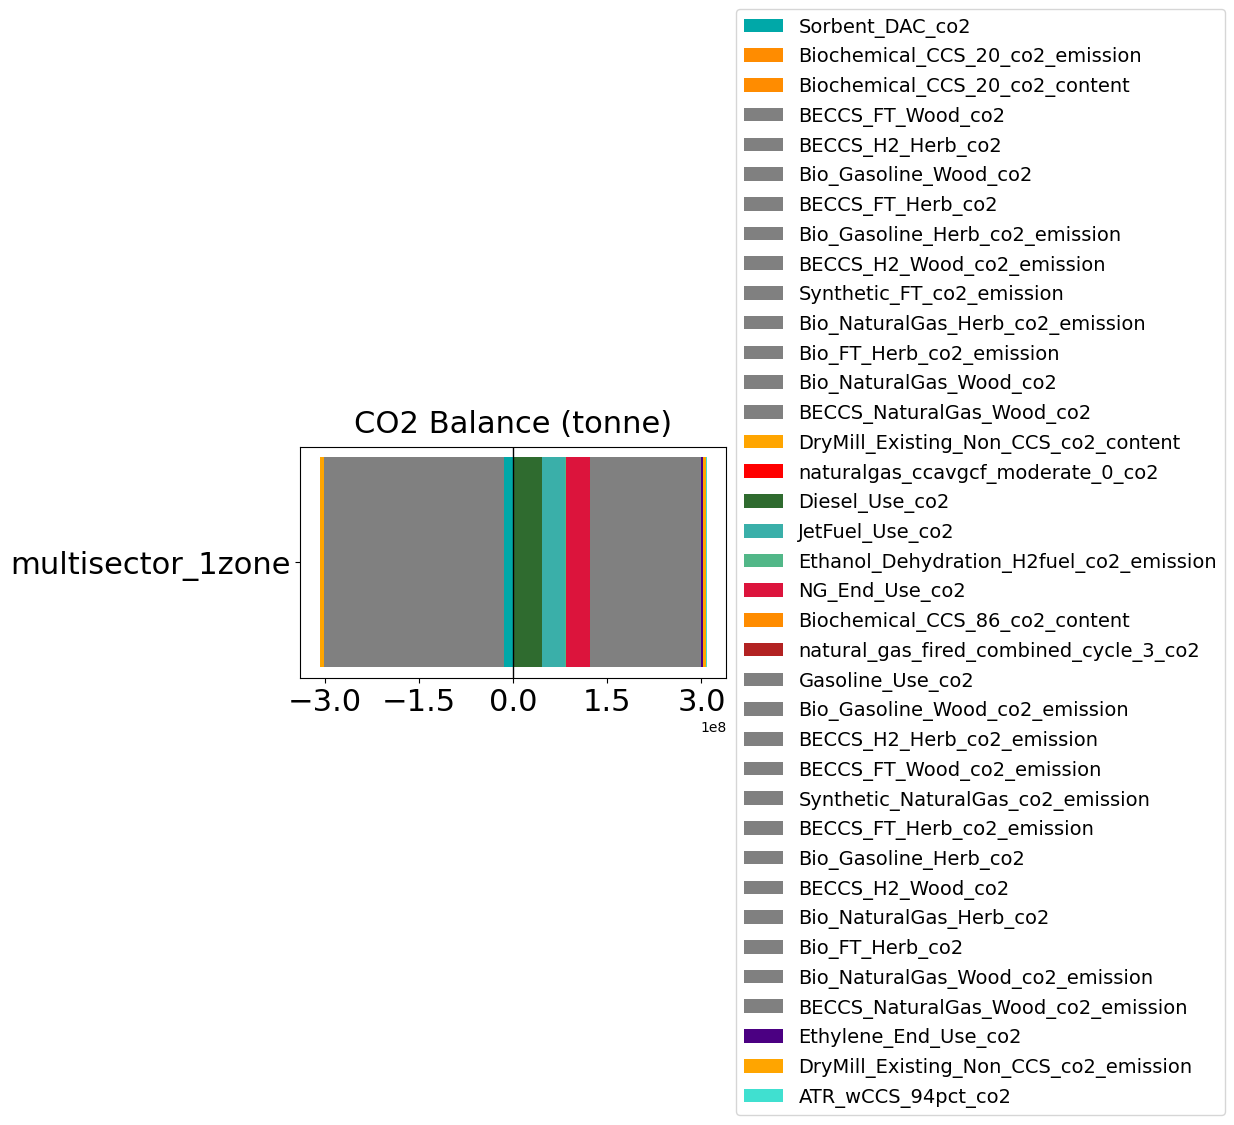

In [98]:
fig, ax = plot_scenario_balance_horizontal_co2_sink(
    data=scenario_plot_dict,
    commodity="CO2",
    scenarios=scenarios_dict_for_plots,
    units="tonnes",
    sort_components=True,
    figsize=(5.5, 3),
    title="CO2 Balance (tonne)"
)

Total Cost: 1.917e11


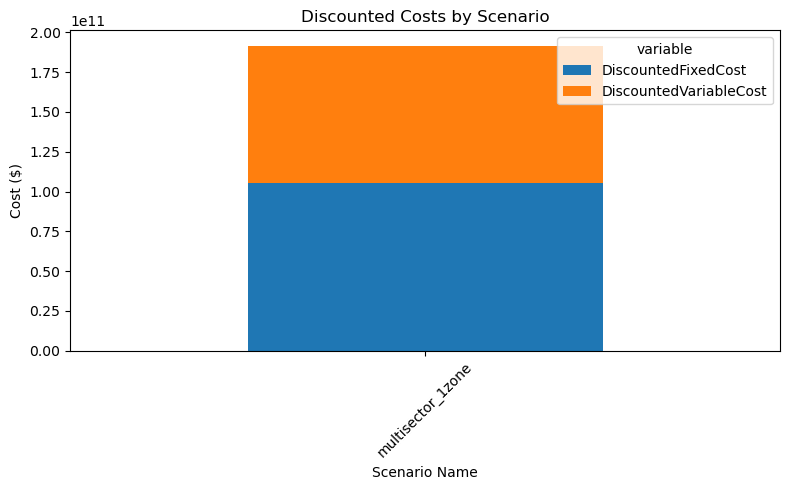

In [99]:
plot_discounted_costs(scenario_plot_dict)


=== Scenario Totals (MWh) ===
multisector_1zone:  +7.51   -7.51


/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/3790479505.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


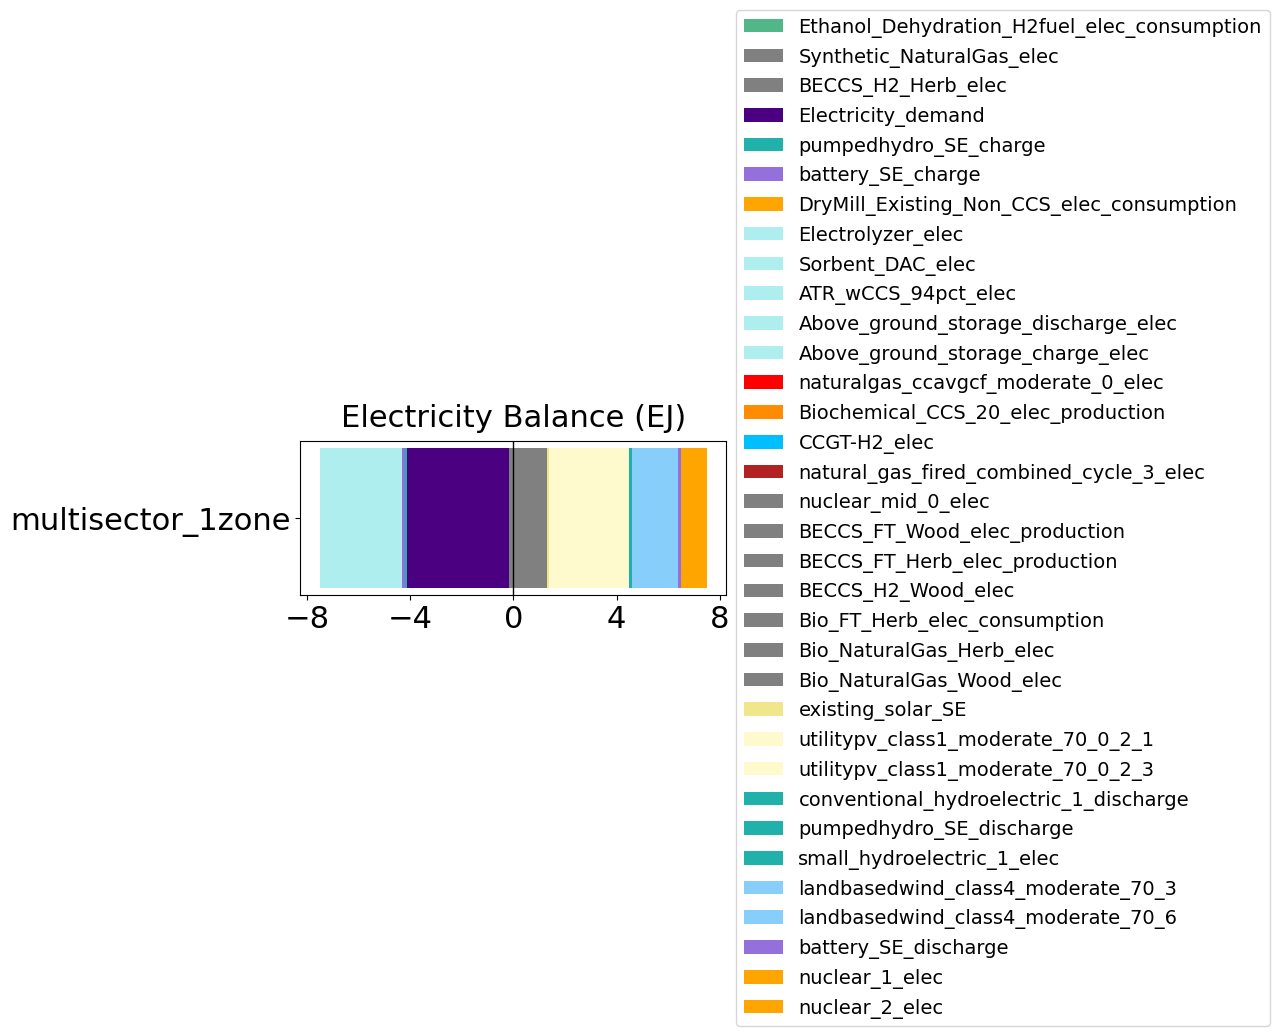

In [100]:
fig, ax = plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Electricity",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    figsize=(5.5, 2),
    title="Electricity Balance (EJ)"
)

/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/3790479505.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])



=== Scenario Totals (MWh) ===
multisector_1zone:  +3.03   -3.03


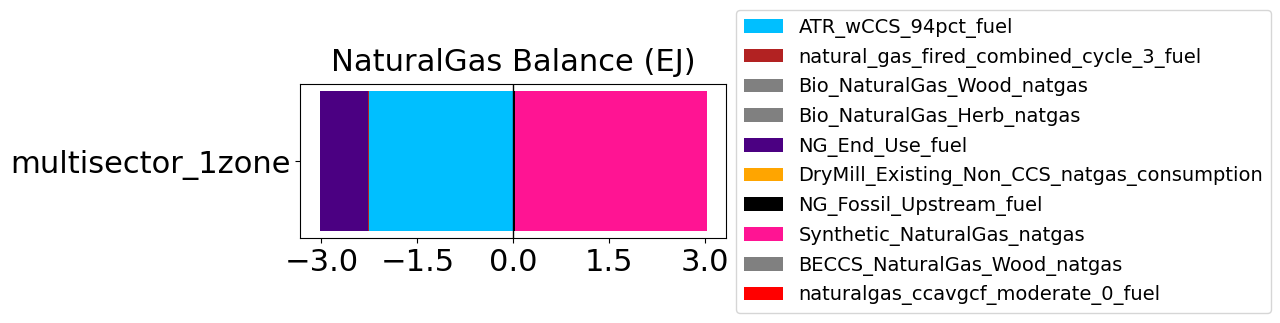

In [101]:
fig, ax = plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="NaturalGas",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    figsize=(5.5, 2),
    title="NaturalGas Balance (EJ)"
)


=== Scenario Totals (MWh) ===
multisector_1zone:  +0.00   -0.00


/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/3790479505.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


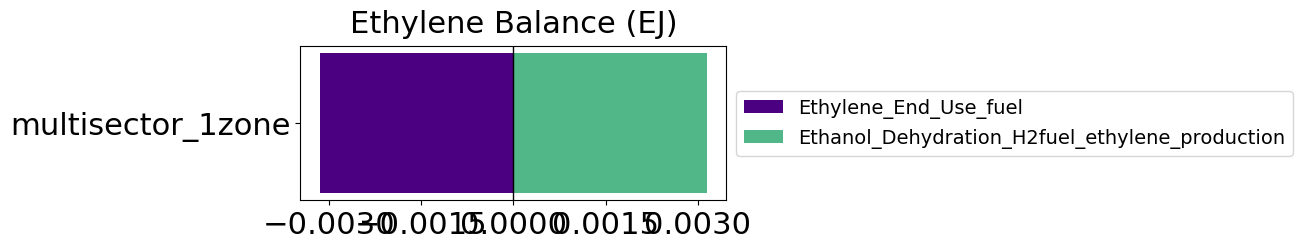

In [102]:
fig, ax = plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Ethylene",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    figsize=(5.5, 2),
    title="Ethylene Balance (EJ)"
)


=== Scenario Totals (MWh) ===
multisector_1zone:  +0.04   -0.04


/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/3790479505.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


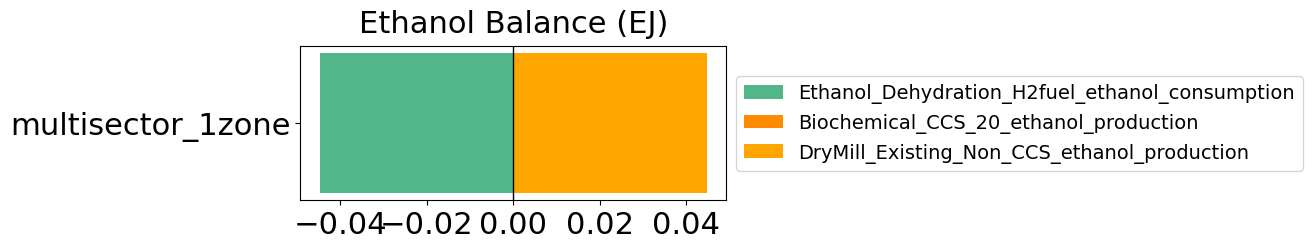

In [103]:
fig, ax = plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Ethanol",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    figsize=(5.5, 2),
    title="Ethanol Balance (EJ)"
)


=== Scenario Totals (MWh) ===
multisector_1zone:  +5.54   -5.08


/var/folders/9l/0ttvb7f127qgtw6nrswqz0r80000gn/T/ipykernel_89877/3790479505.py:174: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


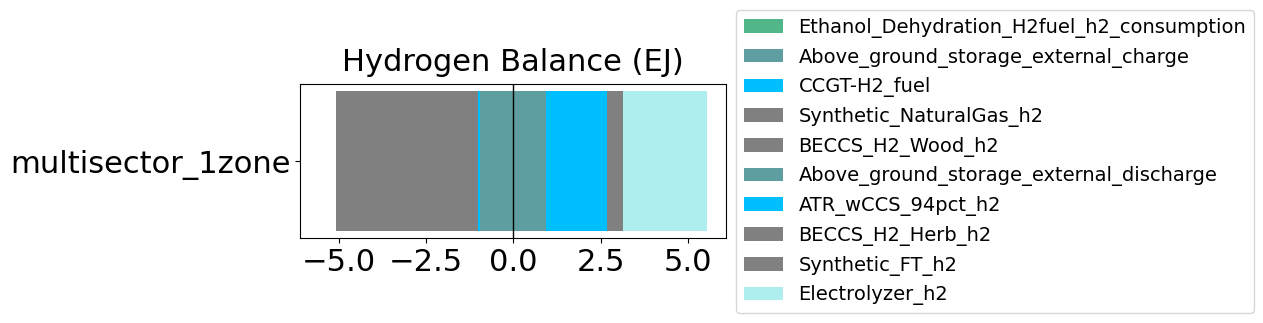

In [104]:
fig, ax = plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Hydrogen",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    figsize=(5.5, 2),
    title="Hydrogen Balance (EJ)"
)

In [105]:
commodities_biomass = ["Biomass_Agri", "Biomass_Herb", "Biomass_Wood"]

df_multi = build_multi_commodity_df(scenario_plot_dict, commodities_biomass, scenarios_dict_for_plots,)
agg_multi = aggregate_multi_commodity(df_multi)

plot_multi_commodity_balance(
    agg_multi,
    scenarios=scenarios_dict_for_plots,
    title="Cellulosic Biomass Usage (tonne)",
    figsize=(7.5, 2),
)

KeyError: 'Biomass_Agri'

In [ ]:
fig, axes = plt.subplots(
    ncols=3,
    figsize=(16, 3),
    sharey=True
)

plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Gasoline",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    title="Gasoline (EJ)",
    ax=axes[0],
    show=False,
    legend=False,
)

plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="Diesel",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    title="Diesel (EJ)",
    ax=axes[1],
    show=False,
    legend=False,
)

plot_scenario_balance_horizontal(
    data=scenario_plot_dict,
    commodity="JetFuel",
    scenarios=scenarios_dict_for_plots,
    units="EJ",
    sort_components=True,
    title="JetFuel (EJ)",
    ax=axes[2],
    show=False,
    legend=False,
)
plt.tight_layout()
plt.show()


In [ ]:
commodities_on_one_scale = ["Gasoline", "Diesel", "JetFuel"]

global_extent = compute_global_extent(
    data=scenario_plot_dict,
    commodities=commodities_on_one_scale,
    scenarios=scenarios_dict_for_plots,
)
x_range = [-1.1 * global_extent, 1.1 * global_extent]
fig = make_subplots(
    rows=1,
    cols=3,
    shared_yaxes=True,
    horizontal_spacing=0.05,
)

fig = plot_scenario_balance_horizontal_plotly_subplot(
    data=scenario_plot_dict,
    commodity="Gasoline",
    scenarios=scenarios_dict_for_plots,
    fig=fig,
    row=1,
    col=1,
    title="Gasoline",
    showlegend=True,   # legend ONLY here
    x_range=x_range,
)

fig = plot_scenario_balance_horizontal_plotly_subplot(
    data=scenario_plot_dict,
    commodity="Diesel",
    scenarios=scenarios_dict_for_plots,
    fig=fig,
    row=1,
    col=2,
    title="Diesel",
    showlegend=False,
    x_range=x_range,
)

fig = plot_scenario_balance_horizontal_plotly_subplot(
    data=scenario_plot_dict,
    commodity="JetFuel",
    scenarios=scenarios_dict_for_plots,
    fig=fig,
    row=1,
    col=3,
    title="Jet Fuel",
    showlegend=False,
    x_range=x_range,
)

fig.update_layout(
    width=1700,
    height=400,
    barmode="relative",
    legend=dict(
        x=1.02,
        y=0.5,
        font=dict(size=14),
    ),
)

fig.show()

## plot-dispatch-display

Found 26 unique grouped resource_ids
Resource IDs: ['SE_BECCS_Electricity_Herb' 'SE_BECCS_Electricity_Wood' 'SE_Bio_FT_Herb'
 'SE_Bio_FT_Wood' 'SE_BECCS_FT_Herb' 'SE_BECCS_FT_Wood'
 'SE_DryMill_Existing_Non_CCS' 'SE_Biochemical_Non_CCS'
 'SE_Biochemical_CCS_20' 'SE_Biochemical_CCS_86' 'battery_SE'
 'pumpedhydro_SE' 'SE_CCGT-H2' 'SE_OCGT-H2'
 'SE_conventional_hydroelectric_1' 'SE_small_hydroelectric_1'
 'SE_Solvent_DAC' 'SE_natural_gas_fired_combined_cycle'
 'SE_natural_gas_fired_combustion_turbine'
 'SE_naturalgas_ccavgcf_moderate_0' 'SE_naturalgas_ctavgcf_moderate_0'
 'SE_naturalgas_ccccsavgcf_conservative_0' 'SE_nuclear' 'SE_utilitypv'
 'SE_landbasedwind_class4_moderate' 'existing_solar_SE']

Rows per grouped resource_id (after aggregation):
  SE_BECCS_Electricity_Herb: 504 rows
  SE_BECCS_Electricity_Wood: 504 rows
  SE_Bio_FT_Herb: 504 rows
  SE_Bio_FT_Wood: 504 rows
  SE_BECCS_FT_Herb: 504 rows
  SE_BECCS_FT_Wood: 504 rows
  SE_DryMill_Existing_Non_CCS: 504 rows
  SE_Biochemical_N

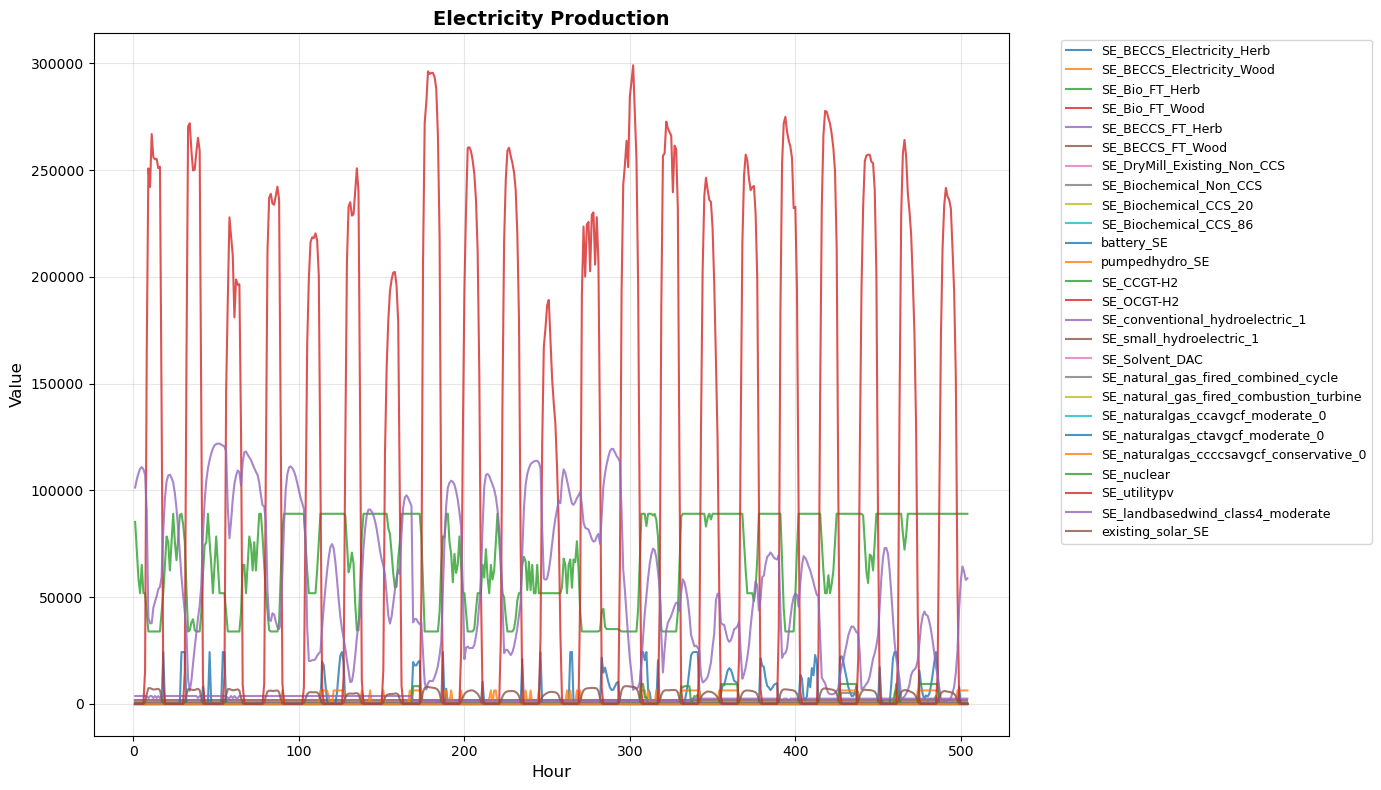

In [45]:
for scenario_label in load_files_dict.keys():
    base_path = Path(load_files_dict[scenario_label]["base_path"])
    folder_name = load_files_dict[scenario_label]["folder_name"]
    results = load_files_dict[scenario_label]["results"]
    
    # Create the file path
    file_path = base_path / folder_name / results / "flows.csv"
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Filter for rows with node_out = 'elec_SE' and commodity = 'Electricity'
    filtered_df = df[(df['node_out'] == 'elec_SE') & (df['commodity'] == 'Electricity')].copy()

    # Create a grouped resource_id column
    def group_resource_id(resource_id):
        """Group similar resource IDs together"""
        if 'natural_gas_fired_combined_cycle' in resource_id:
            return 'SE_natural_gas_fired_combined_cycle'
        elif 'utilitypv' in resource_id:
            return 'SE_utilitypv'
        elif 'natural_gas_fired_combustion_turbine' in resource_id:
            return 'SE_natural_gas_fired_combustion_turbine'
        elif 'landbasedwind_class4_moderate_70' in resource_id:
            return 'SE_landbasedwind_class4_moderate'
        elif 'nuclear' in resource_id:
            return 'SE_nuclear'
        else:
            return resource_id
    
    filtered_df['grouped_resource_id'] = filtered_df['resource_id'].apply(group_resource_id)

    # Get unique grouped resource_ids
    resource_ids = filtered_df['grouped_resource_id'].unique()
    print(f"Found {len(resource_ids)} unique grouped resource_ids")
    print(f"Resource IDs: {resource_ids}")

    # Group by grouped_resource_id and time, summing the values
    grouped_df = filtered_df.groupby(['grouped_resource_id', 'time'])['value'].sum().reset_index()

    print("\nRows per grouped resource_id (after aggregation):")
    for rid in resource_ids:
        count = len(grouped_df[grouped_df['grouped_resource_id'] == rid])
        print(f"  {rid}: {count} rows")

    # Create the plot
    plt.figure(figsize=(14, 8))

    # Plot each grouped resource_id as a separate series
    for resource_id in resource_ids:
        # Get data for this resource_id
        resource_data = grouped_df[grouped_df['grouped_resource_id'] == resource_id].copy()
        
        # Sort by time to ensure proper plotting
        resource_data = resource_data.sort_values('time')
        
        # Plot with resource_id as the label
        plt.plot(resource_data['time'], resource_data['value'], 
                label=resource_id, linewidth=1.5, alpha=0.8)

    # Customize the plot
    plt.xlabel('Hour', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title('Electricity Production', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Show the plot
    plt.show()